DATASET OVERVIEW
Total rows: 456548
Total columns: 9

Column names and types:
id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
dtype: object

First 5 rows:
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2            

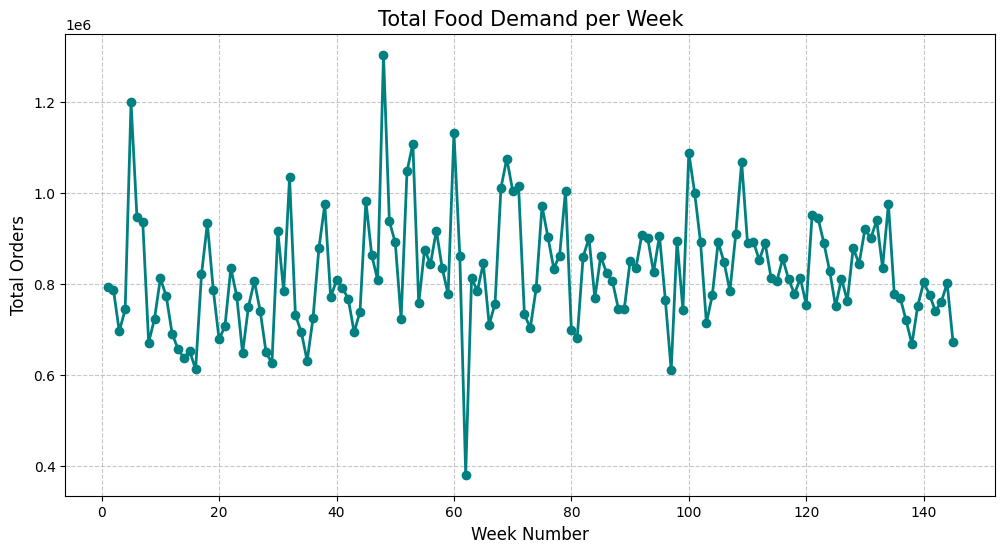

✅ Trend chart displayed and saved to data/processed/trends.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = current_dir.parent.parent
train_file = project_root / 'data' / 'raw' / 'train.csv'

class DataExplorer:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)
    
    def show_basic_info(self):
        """Display dataset information"""
        print("=" * 50)
        print("DATASET OVERVIEW")
        print("=" * 50)
        print(f"Total rows: {len(self.df)}")
        print(f"Total columns: {len(self.df.columns)}")
        print("\nColumn names and types:")
        print(self.df.dtypes)
        print("\nFirst 5 rows:")
        print(self.df.head())
        print("\nMissing values:")
        print(self.df.isnull().sum())
        print("\nBasic statistics:")
        print(self.df.describe())
    
    def visualize_trends(self):
        """Create visualizations based on weekly data"""
        print("\n" + "=" * 50)
        print("GENERATING VISUALIZATIONS")
        print("=" * 50)
        
        # Check for 'week' instead of 'date'
        if 'week' in self.df.columns:
            # Grouping by week and summing the number of orders
            weekly_sales = self.df.groupby('week')['num_orders'].sum()
            
            plt.figure(figsize=(12, 6))
            weekly_sales.plot(kind='line', marker='o', color='teal', linewidth=2)
            
            plt.title('Total Food Demand per Week', fontsize=15)
            plt.xlabel('Week Number', fontsize=12)
            plt.ylabel('Total Orders', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            
            # Ensure the directory exists before saving
            os.makedirs('data/processed', exist_ok=True)
            plt.savefig('data/processed/trends.png')
            
            plt.show() # This will force the image to pop up in your Notebook cell
            print("✅ Trend chart displayed and saved to data/processed/trends.png")
        else:
            print("❌ Could not find 'week' column for plotting.")

# Test it
if __name__ == '__main__':
    explorer = DataExplorer(str(train_file))
    explorer.show_basic_info()
    explorer.visualize_trends()